
# Ray Unit 0 - Ray Intro


## Setup

1. Create the `22971-ray` environment:

   ```bash
   conda env create -f environment.yml
   ```
2. Activate it:

   ```bash
   conda activate 22971-ray
   ```

3. Run this notebook with the `22971-ray` kernel
    > In VS code: top right, "select kernel". 



## 0. Mental model

Ordinary Python function calls are **blocking**:
1. call the function
2. wait
3. get the value back
4. continue to the next line

Ray **tasks** are different:
1. submit the task
2. immediately get back an **ObjectRef**: A reference to an object that doesn't exist yet (a "Future").
3. continue doing other work
4. wait for the value of the task explicitly with `ray.get(...)`

So the real shift is:

- **function call** → gives a value
- **Ray task submission** → gives a reference to a future value


In [1]:
import time
import ray


## 1. Start a local Ray cluster

In [2]:
ray.shutdown()
ray.init()

2026-03-25 10:41:44,246	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.13
Ray version:,2.54.0
Dashboard:,http://127.0.0.1:8265



## 2. A deliberately slow function

We use `sleep` because it makes blocking behavior visible.
The function itself is trivial; the point is the waiting.


In [3]:
def slow_square(x, delay_s=1.0):
    time.sleep(delay_s)
    return x * x


## 3. Baseline: ordinary sequential Python

This is the familiar blocking model.
Each call finishes before the next call begins.


In [4]:

xs = [1, 2, 3, 4]

start = time.perf_counter()
out_seq = [slow_square(x) for x in xs]
elapsed_seq = time.perf_counter() - start

print('Sequential output:', out_seq)
print(f'Sequential elapsed: {elapsed_seq:.2f} seconds')


Sequential output: [1, 4, 9, 16]
Sequential elapsed: 4.00 seconds



With four 1-second calls, sequential execution takes about **4 seconds**: We wait for `slow_square(1)`, then run `slow_square(2)` etc...


## 4. Turn the function into a remote function

In [5]:

@ray.remote
def slow_square_ray(x, delay_s=1.0):
    time.sleep(delay_s)
    return x * x


This function can now run on the Ray cluster. 

For simple functions: adding the `@ray.remote` decorator is enough.


## 5. Invoke a remote function

In [6]:

start = time.perf_counter()
refs = [slow_square_ray.remote(x) for x in xs]
submit_elapsed = time.perf_counter() - start

print('ObjectRefs returned immediately:')
print(refs)
print(f'Submission time: {submit_elapsed:.4f} seconds')


ObjectRefs returned immediately:
[ObjectRef(c8ef45ccd0112571ffffffffffffffffffffffff0100000001000000), ObjectRef(16310a0f0a45af5cffffffffffffffffffffffff0100000001000000), ObjectRef(c2668a65bda616c1ffffffffffffffffffffffff0100000001000000), ObjectRef(32d950ec0ccf9d2affffffffffffffffffffffff0100000001000000)]
Submission time: 0.0393 seconds


This cell runs instantly, why?

1. `slow_square_ray.remote(x)` submits a task to the Ray scheduler.
2.  The scheduler acknowledges submission and returns an ObjectRef, **before the task is executed**.
3.  At the same time: 
    - Our script unblocks and continues executing.
    - The task runs somewhere in the cluster. 

Conclusions: 
1. Our script blocks on the function invocations only for the submission duration (short).  
2. When `print(refs)` is run, the return values don't exist yet.  


## 6. Do other work while Ray tasks run

This is the whole point of async execution:
We are free to do unrelated (local) work before synchronizing.


In [7]:

start_other = time.perf_counter()
local_total = sum(range(2_000_000))
elapsed_other = time.perf_counter() - start_other

print('Did some local work while remote tasks were running.')
print('Local val:', local_total)
print(f'Local work took: {elapsed_other:.4f} seconds')


Did some local work while remote tasks were running.
Local val: 1999999000000
Local work took: 0.0672 seconds



## 7. Synchronization point: `ray.get(...)`


In [8]:

start = time.perf_counter()
output_vals = ray.get(refs)
elapsed_get = time.perf_counter() - start

print('Ray output:', output_vals) #Actual values, not references.
print(f'ray.get(...) wait time: {elapsed_get:.2f} seconds')



Ray output: [1, 4, 9, 16]
ray.get(...) wait time: 1.11 seconds


If you ran the cells manually up till now, this cell should run instantly. Why?

Generally, `ray.get(...)` blocks until:
1. All tasks finish running. 
2. The return values exist. 
3. The objects are available **locally**.

**In our case:** all tasks ran in the background on other workers in the cluster, so all return values exist already. 





## 8. End-to-end timing comparison


In [9]:

start = time.perf_counter()
_ = [slow_square(x, delay_s=1.0) for x in xs]
full_seq = time.perf_counter() - start

start = time.perf_counter()
refs = [slow_square_ray.remote(x, delay_s=1.0) for x in xs]
_ = ray.get(refs)
full_ray = time.perf_counter() - start

print(f'Full sequential time: {full_seq:.2f} seconds')
print(f'Full Ray time:        {full_ray:.2f} seconds')
print(f'Speedup factor:       {full_seq / full_ray:.2f}x')


Full sequential time: 4.00 seconds
Full Ray time:        1.01 seconds
Speedup factor:       3.97x


## 9. Anti-pattern: premature synchronization

In [10]:

start = time.perf_counter()
out_bad = []
for x in xs:
    ref = slow_square_ray.remote(x, delay_s=1.0)
    out_bad.append(ray.get(ref))
elapsed_bad = time.perf_counter() - start

print('Bad pattern output:', out_bad)
print(f'Bad pattern elapsed: {elapsed_bad:.2f} seconds')


Bad pattern output: [1, 4, 9, 16]
Bad pattern elapsed: 4.03 seconds


Why is this slow?

`ray.get(ref)` blocks after each task submission, until task completion. 

`=>` There is only one active task at any given time. 

`=>` The computation runs sequentially, with the added overhead of cluster communication.


## 10. Partial synchronization: `ray.wait(...)`

- `ray.get(refs)` waits for **all** tasks.
- `ray.wait(...)` lets us react when the **next ready** task finishes.
- It returns a list of ready `ObjectRef`s, not the values themselves.


In [18]:

@ray.remote
def slow_task(x, delay_s):
    time.sleep(delay_s)
    return x

delays = [1.5, 0.2, 1.0, 0.5]
pending = [slow_task.remote(x, delay_s=d) for x, d in zip(xs, delays)]

completion_order = []
while pending:
    ready_refs, pending = ray.wait(pending, num_returns=1)
    ready_val = ray.get(ready_refs[0])
    completion_order.append(ready_val)
    print(f'next finished x: {ready_val} | {len(pending)} tasks still pending')

print('Completion order:', completion_order)

next finished x: 2 | 3 tasks still pending
next finished x: 4 | 2 tasks still pending
next finished x: 3 | 1 tasks still pending
next finished x: 1 | 0 tasks still pending
Completion order: [2, 4, 3, 1]



## 11. Summary
1. `@ray.remote` creates a remote function.
2. `.remote(...)` starts work and returns an `ObjectRef` immediately.
3. `ray.get(...)` is a full synchronization point.
4. `ray.wait(...)` lets us synchronize incrementally.
5. Premature synchronization destroys concurrency.


## 12. Optional exercises

1. Change `xs` from 4 tasks to 8 or 16. What happens to the timings?
2. Change the delay from `1.0` to `0.1`. At what point does cluster scheduling overhead start to matter?
3. Insert `time.sleep(0.5)` between submissions. How does that affect `ray.get(...)` wait time?


## 13. Shutdown

1. The cluster fate-shares with the driver process (the python process that ran `ray.init()`). 
2. Cluster components should terminate when the driver exits, but this is not always clean. 

Shutdown the cluster explicitly to avoid zombie subprocesses.

In [12]:
ray.shutdown()

## 14. Cluster components
Source: [Ray whitepaper](https://docs.google.com/document/d/1tBw9A4j62ruI5omIJbMxly-la5w4q_TjyJgJL_jN2fI)

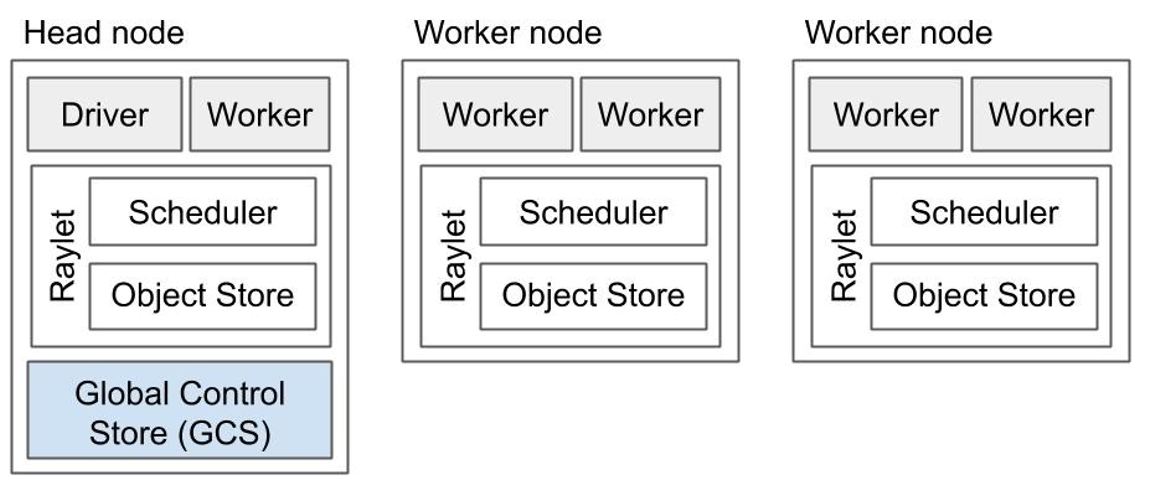